## Merging SI poplave data

## Setup


In [1]:
!which python
# !pip install nbformat pandas plotly requests
# !pip install nbformat --upgrade
# !pip install plotly

/Users/klemenkubelj/miniconda3/envs/cvar-masters/bin/python


In [2]:
%load_ext autoreload
%autoreload 2

In [40]:
import os
import geopandas as gpd

### Define paths

In [4]:
DATA_DIR = "/Users/klemenkubelj/Documents/school/graduate/masters/data/Karte Globine - December"

In [22]:
# List all directories in the data path
all_dirs = [p for p in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, p)) and p.startswith("OPVP")]
for d in sorted(all_dirs):
    print(d)


OPVP Begunje na Gorenjskem
OPVP Cerkno
OPVP Črna na Koroškem
OPVP Hrastovec
OPVP Izola
OPVP Kostanjevica
OPVP Kresnice
OPVP Kropa
OPVP Krška vas
OPVP Litija
OPVP Miren
OPVP Odranci
OPVP Ortnek
OPVP Piran
OPVP Radeče
OPVP Solčava
OPVP Tržič
OPVP Zagorje ob Savi


### Add prj files

In [35]:
epsg_3912 = """
PROJCS["MGI_1901_Slovene_National_Grid",GEOGCS["GCS_MGI_1901",DATUM["D_MGI_1901",SPHEROID["Bessel_1841",6377397.155,299.1528128]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",-5000000.0],PARAMETER["Central_Meridian",15.0],PARAMETER["Scale_Factor",0.9999],PARAMETER["Latitude_Of_Origin",0.0],UNIT["Meter",1.0]]
""".replace("\n", "")

def add_prj_file_to_shapefile(shapefile_path, force_recreate=True):
    if not os.path.exists(shapefile_path):
        raise FileNotFoundError(f"Shapefile not found: '{shapefile_path}'")
    if not shapefile_path.endswith(".shp"):
        raise ValueError(f"Shapefile path must end with '.shp': '{shapefile_path}'")
    
    # Check if prj file exists
    prj_file = shapefile_path.replace(".shp", ".prj")
    if os.path.exists(prj_file):
        if force_recreate:
            os.remove(prj_file)
        else:
            # print(f"Prj file already exists for '{shapefile_path}'")
            return False
    
    # Create prj file
    with open(prj_file, "w") as f:
        f.write(epsg_3912)
    return True


In [37]:
# Iterate over all files in the directory
stats = {
    "new": 0,
    "existing": 0,
}
for d in all_dirs:
    dir_path = os.path.join(DATA_DIR, d)
    # walk through the directory
    for root, dirs, files in os.walk(dir_path):
        for f in files:
            if f.endswith(".shp"):
                shp_file = os.path.join(root, f)
                added = add_prj_file_to_shapefile(shp_file, force_recreate=False)
                if added:
                    stats["new"] += 1
                else:
                    stats["existing"] += 1
print(stats)


{'new': 0, 'existing': 225}


# Merge shapefiles for Q10

In [59]:
rad_q10v = '/Users/klemenkubelj/Documents/school/graduate/masters/data/Karte Globine - December/OPVP Radeče/shape/Q10gv.shp'
rad_q10s = '/Users/klemenkubelj/Documents/school/graduate/masters/data/Karte Globine - December/OPVP Radeče/shape/Q10gs.shp'
rad_q10m = '/Users/klemenkubelj/Documents/school/graduate/masters/data/Karte Globine - December/OPVP Radeče/shape/Q10gm.shp'
rad_q10 = '/Users/klemenkubelj/Documents/school/graduate/masters/data/Karte Globine - December/OPVP Radeče/shape/Q10.shp'

In [80]:
def _get_globina(row):
    source = row["source"].lower()
    if source.endswith("q10gv.shp"):
        return 2
    elif source.endswith("q10gs.shp"):
        return 1
    elif source.endswith("q10gm.shp"):
        return 0.5
    raise ValueError(f"Unknown source: '{source}'")

def _clean_shapefile(_df, path):
    _df["source"] = os.path.relpath(path, DATA_DIR)
    _df["globina"] = _df.apply(lambda row: _get_globina(row), axis=1)
    return _df

def _read_shapefile(path):
    _df = gpd.read_file(path)
    _df = _clean_shapefile(_df, path)
    return _df


df_rad_q10v = _read_shapefile(rad_q10v)
df_rad_q10s = _read_shapefile(rad_q10s)
df_rad_q10m = _read_shapefile(rad_q10m)

In [81]:
df_rad_q10v

,Id,UREDB_PRAV,DIM_HID_M,OZN_K,OP_OZN_K,Q_G,IME_IZD,OPOMBA,geometry,source,globina
0,0,skladno po pravilniku,1-2D in 2D,Q10gv,"(območje) globin pri pretoku Q10: >1,5 m",Q,iS Projekt d.o.o.,/,"POLYGON ((513388.550 102215.093, 513368.264 10...",OPVP Radeče/shape/Q10gv.shp,2
1,0,skladno po pravilniku,1-2D in 2D,Q10gv,"(območje) globin pri pretoku Q10: >1,5 m",Q,iS Projekt d.o.o.,/,"POLYGON ((513366.688 102072.736, 513359.253 10...",OPVP Radeče/shape/Q10gv.shp,2
2,0,skladno po pravilniku,1-2D in 2D,Q10gv,"(območje) globin pri pretoku Q10: >1,5 m",Q,iS Projekt d.o.o.,/,"POLYGON ((512807.321 102207.395, 512803.543 10...",OPVP Radeče/shape/Q10gv.shp,2


In [83]:
df_rad_q10m

,Id,UREDB_PRAV,DIM_HID_M,OZN_K,OP_OZN_K,Q_G,IME_IZD,OPOMBA,Shape_Leng,Shape_Area,geometry,source,globina
0,0,skladno po pravilniku,1-2D in 2D,Q10,meja območja pri pretoku Q10,Q,iS Projekt d.o.o.,/,136.185664,450.693966,"POLYGON ((513012.395 102393.702, 513009.065 10...",OPVP Radeče/shape/Q10gm.shp,0.5
1,0,skladno po pravilniku,1-2D in 2D,Q10,meja območja pri pretoku Q10,Q,iS Projekt d.o.o.,/,72.234608,31.440314,"MULTIPOLYGON (((512973.787 102636.031, 512973....",OPVP Radeče/shape/Q10gm.shp,0.5
2,0,skladno po pravilniku,1-2D in 2D,Q10,meja območja pri pretoku Q10,Q,iS Projekt d.o.o.,/,336.364022,957.254837,"POLYGON ((513273.301 102555.046, 513272.458 10...",OPVP Radeče/shape/Q10gm.shp,0.5
3,0,skladno po pravilniku,1-2D in 2D,Q10,meja območja pri pretoku Q10,Q,iS Projekt d.o.o.,/,303.151514,890.513941,"POLYGON ((513176.572 102487.197, 513175.934 10...",OPVP Radeče/shape/Q10gm.shp,0.5
4,0,skladno po pravilniku,1-2D in 2D,Q10,meja območja pri pretoku Q10,Q,iS Projekt d.o.o.,/,133.890483,131.153413,"MULTIPOLYGON (((513366.075 102205.953, 513361....",OPVP Radeče/shape/Q10gm.shp,0.5
5,0,skladno po pravilniku,1-2D in 2D,Q10,meja območja pri pretoku Q10,Q,iS Projekt d.o.o.,/,17.322600,10.075179,"POLYGON ((513343.370 102181.530, 513339.152 10...",OPVP Radeče/shape/Q10gm.shp,0.5
6,0,skladno po pravilniku,1-2D in 2D,Q10,meja območja pri pretoku Q10,Q,iS Projekt d.o.o.,/,26.144018,9.608687,"POLYGON ((513322.561 102172.152, 513320.512 10...",OPVP Radeče/shape/Q10gm.shp,0.5
7,0,skladno po pravilniku,1-2D in 2D,Q10,meja območja pri pretoku Q10,Q,iS Projekt d.o.o.,/,39.343308,21.820280,"MULTIPOLYGON (((513295.528 102158.803, 513291....",OPVP Radeče/shape/Q10gm.shp,0.5
8,0,skladno po pravilniku,1-2D in 2D,Q10,meja območja pri pretoku Q10,Q,iS Projekt d.o.o.,/,198.654463,129.918400,"MULTIPOLYGON (((513217.748 102141.943, 513225....",OPVP Radeče/shape/Q10gm.shp,0.5
9,0,skladno po pravilniku,1-2D in 2D,Q10,meja območja pri pretoku Q10,Q,iS Projekt d.o.o.,/,19.592259,9.192811,"POLYGON ((512893.556 102208.332, 512892.620 10...",OPVP Radeče/shape/Q10gm.shp,0.5


In [69]:
df_rad_q10v = gpd.read_file(rad_q10v)
df_rad_q10s = gpd.read_file(rad_q10s)
df_rad_q10m = gpd.read_file(rad_q10m)
df_rad_q10m["OP_OZN_K"] = "(območje) globin pri pretoku Q10: <0,5 m"
# df_rad_q10 = gpd.read_file(rad_q10)

print(df_rad_q10v.shape)
print(df_rad_q10s.shape)
print(df_rad_q10m.shape)
# print(df_rad_q10.shape)

(3, 9)
(7, 10)
(26, 11)


(36, 11)


<Axes: >

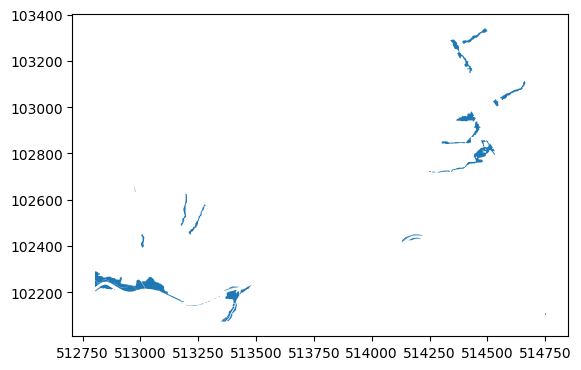

In [70]:
# Merge the 3 dataframes
df_rad_q10 = pd.concat([df_rad_q10v, df_rad_q10s, df_rad_q10m])
print(df_rad_q10.shape)
df_rad_q10.plot()

In [71]:
df_rad_q10

,Id,UREDB_PRAV,DIM_HID_M,OZN_K,OP_OZN_K,Q_G,IME_IZD,OPOMBA,geometry,Shape_Leng,Shape_Area
0,0.0,skladno po pravilniku,1-2D in 2D,Q10gv,"(območje) globin pri pretoku Q10: >1,5 m",Q,iS Projekt d.o.o.,/,"POLYGON ((513388.550 102215.093, 513368.264 10...",NaN,NaN
1,0.0,skladno po pravilniku,1-2D in 2D,Q10gv,"(območje) globin pri pretoku Q10: >1,5 m",Q,iS Projekt d.o.o.,/,"POLYGON ((513366.688 102072.736, 513359.253 10...",NaN,NaN
2,0.0,skladno po pravilniku,1-2D in 2D,Q10gv,"(območje) globin pri pretoku Q10: >1,5 m",Q,iS Projekt d.o.o.,/,"POLYGON ((512807.321 102207.395, 512803.543 10...",NaN,NaN
0,NaN,skladno po pravilniku,1-2D in 2D,Q10gs,"(območje) globin pri pretoku Q10: 0,5-1,5 m",Q,iS Projekt d.o.o.,/,"POLYGON ((513323.945 102174.411, 513323.638 10...",0.737579,0.020167
1,NaN,skladno po pravilniku,1-2D in 2D,Q10gs,"(območje) globin pri pretoku Q10: 0,5-1,5 m",Q,iS Projekt d.o.o.,/,"POLYGON ((513384.486 102093.618, 513380.549 10...",91.039611,302.641061
2,NaN,skladno po pravilniku,1-2D in 2D,Q10gs,"(območje) globin pri pretoku Q10: 0,5-1,5 m",Q,iS Projekt d.o.o.,/,"MULTIPOLYGON (((513247.031 102143.572, 513240....",328.059293,406.835645
3,NaN,skladno po pravilniku,1-2D in 2D,Q10gs,"(območje) globin pri pretoku Q10: 0,5-1,5 m",Q,iS Projekt d.o.o.,/,"MULTIPOLYGON (((513062.233 102209.616, 513065....",99.536913,52.432997
4,NaN,skladno po pravilniku,1-2D in 2D,Q10gs,"(območje) globin pri pretoku Q10: 0,5-1,5 m",Q,iS Projekt d.o.o.,/,"MULTIPOLYGON (((512873.267 102239.754, 512874....",470.210270,2016.829872
5,NaN,skladno po pravilniku,1-2D in 2D,Q10gs,"(območje) globin pri pretoku Q10: 0,5-1,5 m",Q,iS Projekt d.o.o.,/,"POLYGON ((512806.654 102205.079, 512803.543 10...",56.361412,91.122352
6,NaN,skladno po pravilniku,1-2D in 2D,Q10gs,"(območje) globin pri pretoku Q10: 0,5-1,5 m",Q,iS Projekt d.o.o.,/,"POLYGON ((514209.448 102446.132, 514217.026 10...",187.778073,174.777394
